In [125]:
import sys
import os

sys.path.append('../')

from toloof import *

from AnalysisFunctions import plot_enmap

In [2]:
testimclass = Fraunhofer_Image(2E-3,1./3600.,6./60.)

In [3]:
testimclass.set_LMT_aperture()
testimclass.get_zernike_polynomials(4,4)

In [94]:
zern_coffificients_microns = np.zeros(testimclass.zernike_polynomials.shape[0])

zern_coffificients_microns[0] = 0. # piston
zern_coffificients_microns[1] = 0. # TILT_Y
zern_coffificients_microns[2] = 0. # TILT_X
zern_coffificients_microns[3] = 0. # AST_O
zern_coffificients_microns[4] = 0. # FOCUS
zern_coffificients_microns[5] = 0.75 # AST_V
zern_coffificients_microns[6] = 0. # TRE_V
zern_coffificients_microns[7] = 0. # COMA_V
zern_coffificients_microns[8] = 0. # COMA_H
zern_coffificients_microns[9] = 0. # TRE_O
zern_coffificients_microns[10] = 0. # QUAD_O
zern_coffificients_microns[11] = 0. # AST2_O
zern_coffificients_microns[12] = 0. # SPH
zern_coffificients_microns[13] = 0. # AST2_V
zern_coffificients_microns[14] = 0. # QUAD_V

# the function takes the zernike coefficients in phase units

zern_coffificients_phase = zern_coffificients_microns*1E-6*2.*np.pi/testimclass.wavelength

secondary_mirror_offsets = np.zeros(5)

#secondary_mirror_offsets[0] = 

testimclass.set_phase(c=zern_coffificients_phase,secondary_offset=0.E-3,del_x=0.,del_y=-5E-3,del_alph_x=0.,del_alph_y=0.,
                      f=17.5,F=525.,D=50.,plot_phase=False)

In [95]:
testimclass.set_illumination(aperture_fwhm = 48.,edge_taper_diameter=48.,plot_illumination=False)
testimclass.make_normalizing_amplitude()
testimclass.make_psf()

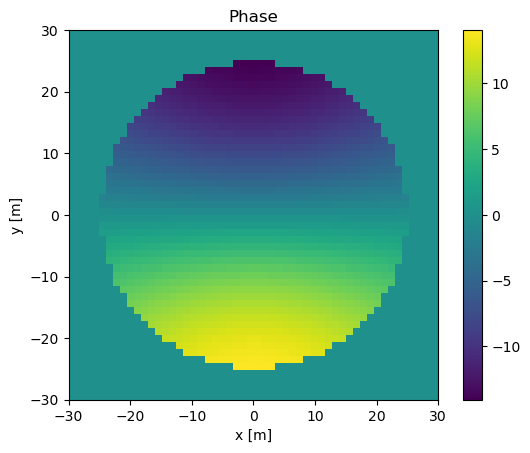

In [96]:
testimclass.plot_phase(plot_vmin=None,plot_vmax=None,save_fig_name=None,noshow=False)

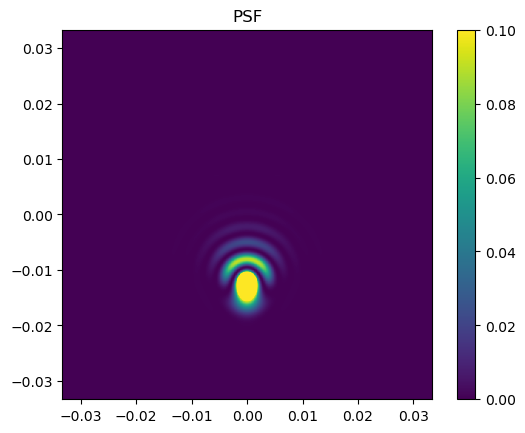

In [97]:
boxsize=2./60.
testimclass.plot_psf(plot_vmin=None,plot_vmax=0.1,save_fig_name=None,xlims=[-boxsize,boxsize],ylims=[-boxsize,boxsize])

In [169]:
# empirically test tilt vs pointing 

testimclass_a2000 = Fraunhofer_Image(2E-3,1./3600.,6./60.)
testimclass_a1400 = Fraunhofer_Image(1.4E-3,1./3600.,6./60.)
testimclass_a1100 = Fraunhofer_Image(1.1E-3,1./3600.,6./60.)

testimclass_a2000.set_LMT_aperture()
testimclass_a2000.get_zernike_polynomials(4,4)
testimclass_a2000.set_illumination(aperture_fwhm = 45.,edge_taper_diameter=45.,plot_illumination=False)
testimclass_a2000.make_normalizing_amplitude()

testimclass_a1400.set_LMT_aperture()
testimclass_a1400.get_zernike_polynomials(4,4)
testimclass_a1400.set_illumination(aperture_fwhm = 45.,edge_taper_diameter=45.,plot_illumination=False)
testimclass_a1400.make_normalizing_amplitude()

testimclass_a1100.set_LMT_aperture()
testimclass_a1100.get_zernike_polynomials(4,4)
testimclass_a1100.set_illumination(aperture_fwhm = 45.,edge_taper_diameter=45.,plot_illumination=False)
testimclass_a1100.make_normalizing_amplitude()

secondary_offsets = np.linspace(-1E-3,1E-3,3)

maps_a2000 = {}
maps_a1400 = {}
maps_a1100 = {}

zern_coffificients_microns = np.zeros(testimclass.zernike_polynomials.shape[0])

zern_coffificients_microns[0] = 0. # piston
zern_coffificients_microns[1] = 0. # TILT_Y
zern_coffificients_microns[2] = 0. # TILT_X
zern_coffificients_microns[3] = 0. # AST_O
zern_coffificients_microns[4] = 0. # FOCUS
zern_coffificients_microns[5] = 250. # AST_V
zern_coffificients_microns[6] = 0. # TRE_V
zern_coffificients_microns[7] = 0. # COMA_V
zern_coffificients_microns[8] = 0. # COMA_H
zern_coffificients_microns[9] = 0. # TRE_O
zern_coffificients_microns[10] = 0. # QUAD_O
zern_coffificients_microns[11] = 0. # AST2_O
zern_coffificients_microns[12] = 0. # SPH
zern_coffificients_microns[13] = 0. # AST2_V
zern_coffificients_microns[14] = 0. # QUAD_V

# the function takes the zernike coefficients in phase units

zern_coffificients_phase_a2000 = zern_coffificients_microns*1E-6*2.*np.pi/testimclass_a2000.wavelength
zern_coffificients_phase_a1400 = zern_coffificients_microns*1E-6*2.*np.pi/testimclass_a1400.wavelength
zern_coffificients_phase_a1100 = zern_coffificients_microns*1E-6*2.*np.pi/testimclass_a1100.wavelength

for count,i in enumerate(secondary_offsets):

    testimclass_a2000.set_phase(c=zern_coffificients_phase_a2000,secondary_offset=i,del_x=0.,del_y=-0E-3,del_alph_x=0.,del_alph_y=0.,
                      f=17.5,F=525.,D=50.,plot_phase=False)
    testimclass_a1400.set_phase(c=zern_coffificients_phase_a1400,secondary_offset=i,del_x=0.,del_y=-0E-3,del_alph_x=0.,del_alph_y=0.,
                      f=17.5,F=525.,D=50.,plot_phase=False)
    testimclass_a1100.set_phase(c=zern_coffificients_phase_a1100,secondary_offset=i,del_x=0.,del_y=-0E-3,del_alph_x=0.,del_alph_y=0.,
                      f=17.5,F=525.,D=50.,plot_phase=False)
    testimclass_a2000.make_psf()
    testimclass_a1400.make_psf()
    testimclass_a1100.make_psf()

    maps_a2000[f'map{count}'] = testimclass_a2000.PSF
    maps_a1400[f'map{count}'] = testimclass_a1400.PSF
    maps_a1100[f'map{count}'] = testimclass_a1100.PSF

    


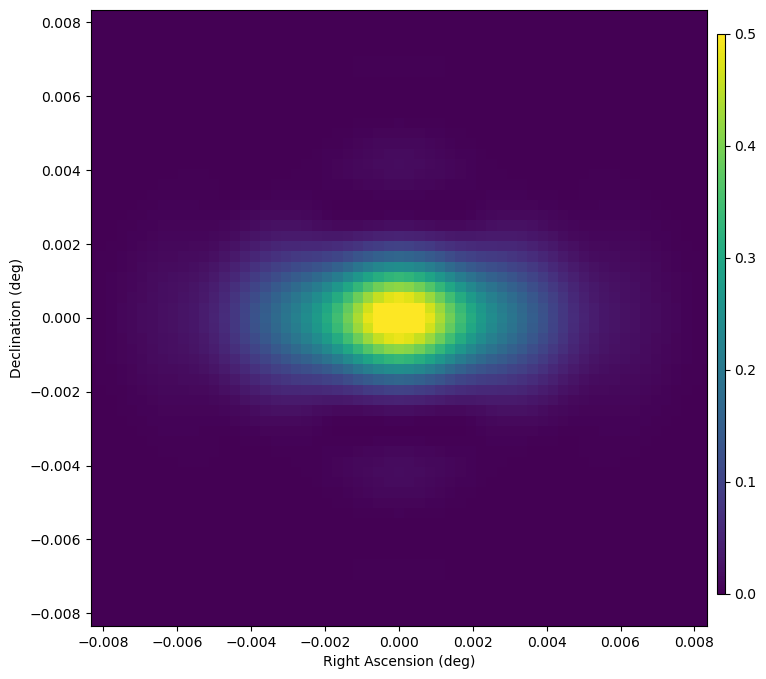

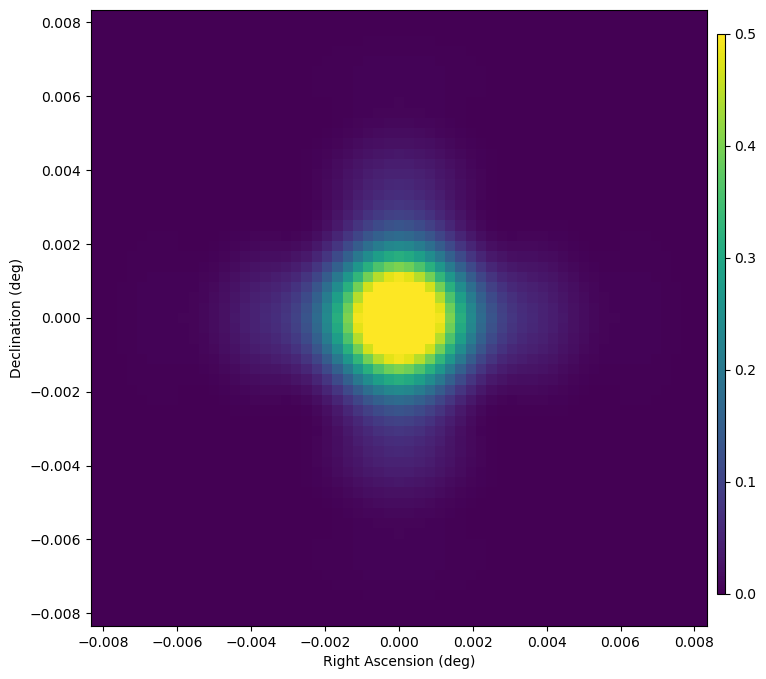

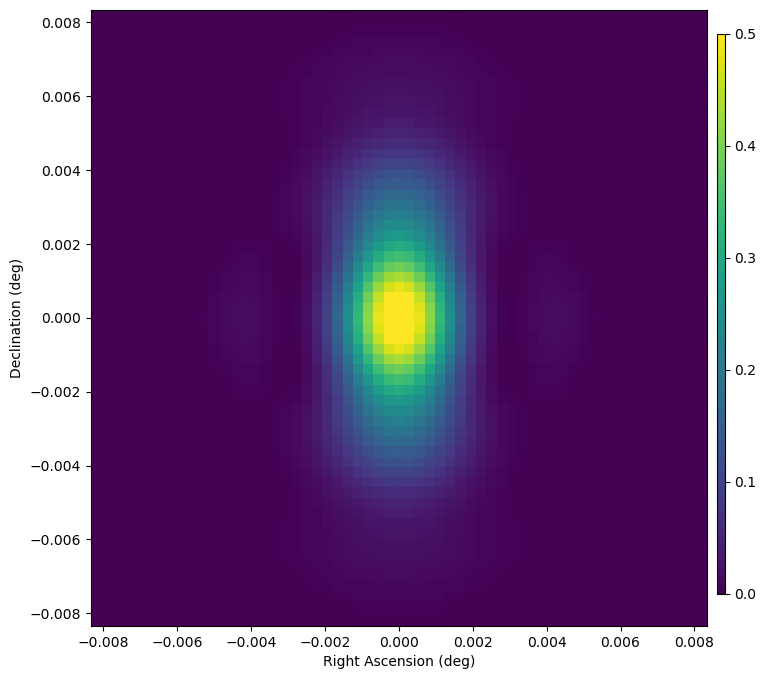

In [170]:
plot_enmap(maps_a2000['map0'],plot_vmax=0.5,xlims=[-0.5/60,0.5/60.],ylims=[-0.5/60,0.5/60.])
plot_enmap(maps_a2000['map1'],plot_vmax=0.5,xlims=[-0.5/60,0.5/60.],ylims=[-0.5/60,0.5/60.])
plot_enmap(maps_a2000['map2'],plot_vmax=0.5,xlims=[-0.5/60,0.5/60.],ylims=[-0.5/60,0.5/60.])

In [109]:
tmppeakloc_a2000[0][0]

-0.0030555555526448046